# **Aprendizaje Automático 1**
## EDA - Modelo estimación valor inmuebles (predicción de MEDV)

**Integrantes:** Alejandro Acosta, Diego Hauret, Gastón Rinaldi, Agustín Torres

Análisis exploratorio de datos previo a la construcción de un modelo de regresión para predecir **MEDV** (valor medio de las viviendas, en miles de USD).

**Indice:**
1. Carga y comprensión de los datos
2. Análisis de valores faltantes
3. Imputación de valores faltantes (ejemplo)
4. Análisis univariado (variable objetivo y predictoras)
5. Análisis bivariado (correlaciones y relación con MEDV)
6. Multicolinealidad entre predictoras
7. Detección de outliers
8. Conclusiones y próximos pasos


## 0. Carga de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Carga y comprensión de los datos

Diccionario de variables:

| Variable | Descripción |
|---|---|
| CRIM | Tasa de criminalidad per cápita por localidad |
| ZN | % de suelo residencial en lotes grandes |
| INDUS | % de acres de negocio no minorista por localidad |
| CHAS | Variable dummy (1 si limita con el río Charles, 0 si no) |
| NOX | Concentración de óxidos de nitrógeno |
| RM | Promedio de habitaciones por vivienda |
| AGE | % de viviendas ocupadas por el propietario construidas antes de 1940 |
| DIS | Distancia ponderada a 5 centros de empleo de Boston |
| RAD | Índice de accesibilidad a autopistas radiales |
| TAX | Tasa de impuesto a la propiedad por cada $10.000 |
| PTRATIO | Ratio alumno-profesor por localidad |
| B | 1000(Bk - 0.63)^2, donde Bk es la proporción de población afroamericana |
| LSTAT | % de población de estatus socioeconómico bajo |
| MEDV | **Variable objetivo**: valor medio de la vivienda (en miles de USD) |


In [68]:
df = pd.read_csv('../data/house-prices-tp.csv')
print("Dimensiones:", df.shape)
df.head()


Dimensiones: (556, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000


In [44]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [45]:
df.describe().T
desc = df.describe().T
desc['mediana'] = df.median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df.skew()
desc['curtosis'] = df.kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 80)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]


Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.8455,0.3153,13.8286,236.5681,0.0063,0.0845,0.3153,4.8714,88.9762,3.7467,15.2487
ZN,13.1972,0.0000,24.9030,188.6993,0.0000,0.0000,0.0000,20.0000,100.0000,1.9578,2.7498
INDUS,11.2187,9.6900,6.9420,61.8789,0.4600,5.1300,9.6900,18.1000,27.7400,0.3015,-1.2064
CHAS,0.0901,0.0000,0.2865,318.1691,0.0000,0.0000,0.0000,0.0000,1.0000,2.8722,6.2731
NOX,0.5600,0.5380,0.1195,21.3325,0.3850,0.4530,0.5380,0.6440,0.8710,0.6944,-0.2296
RM,6.2918,6.2080,0.7824,12.4352,3.5610,5.8755,6.2080,6.6385,8.7800,0.3738,1.5551
AGE,67.6323,76.5000,28.4619,42.0833,2.9000,42.2750,76.5000,93.8250,100.0000,-0.5507,-1.0382
DIS,3.9441,3.3401,2.2557,57.1914,1.1296,2.1121,3.3401,5.4007,12.1265,1.0789,0.7054
RAD,9.6994,5.0000,8.6845,89.5366,1.0000,4.0000,5.0000,23.6327,24.0000,0.9515,-0.9478
TAX,409.5751,335.0000,167.6894,40.9423,187.0000,279.0000,335.0000,666.0000,711.0000,0.6323,-1.1705


In [46]:
print("Filas duplicadas:", df.duplicated().sum())


Filas duplicadas: 0


## 2. Análisis de valores faltantes


Revisamos cuántos nulos tiene cada columna y si hay algún patrón (filas con muchos nulos a la vez, o nulos concentrados).


In [47]:
faltante = df.isna().sum().sort_values(ascending=False)
faltante_pct = (faltante / len(df) * 100).round(2)
print("Cantidad de nulos por columna:")
pd.DataFrame({"nulos": faltante, "% nulos": faltante_pct})


Cantidad de nulos por columna:


,nulos,% nulos
PTRATIO,28,5.0400
RAD,28,5.0400
NOX,24,4.3200
AGE,24,4.3200
CHAS,23,4.1400
CRIM,23,4.1400
LSTAT,22,3.9600
B,22,3.9600
ZN,22,3.9600
RM,21,3.7800


Se observa que la variable objetivo (MEDV) tiene 21 valores faltantes. Estos registros se eliminan porque son valores NaN de la variable a predecir.

In [48]:
df = df.dropna(subset=["MEDV"])
print("Filas con nulos en MEDV:", df["MEDV"].isna().sum())

Filas con nulos en MEDV: 0


In [49]:
faltante = df.isna().sum().sort_values(ascending=False)
faltante_pct = (faltante / len(df) * 100).round(2)
print("Cantidad de nulos por columna:")
pd.DataFrame({"nulos": faltante, "% nulos": faltante_pct})


Cantidad de nulos por columna:


,nulos,% nulos
RAD,12,2.2400
CRIM,11,2.0600
AGE,11,2.0600
ZN,11,2.0600
CHAS,9,1.6800
NOX,9,1.6800
LSTAT,9,1.6800
B,9,1.6800
TAX,9,1.6800
PTRATIO,9,1.6800


In [50]:
nulos_por_fila = df.isna().sum(axis=1)
print("Cantidad de nulos por fila:\n",nulos_por_fila.value_counts().sort_index())


Cantidad de nulos por fila:
 0    506
1      5
2      3
3      9
4      2
5      2
6      1
7      4
8      2
9      1
Name: count, dtype: int64


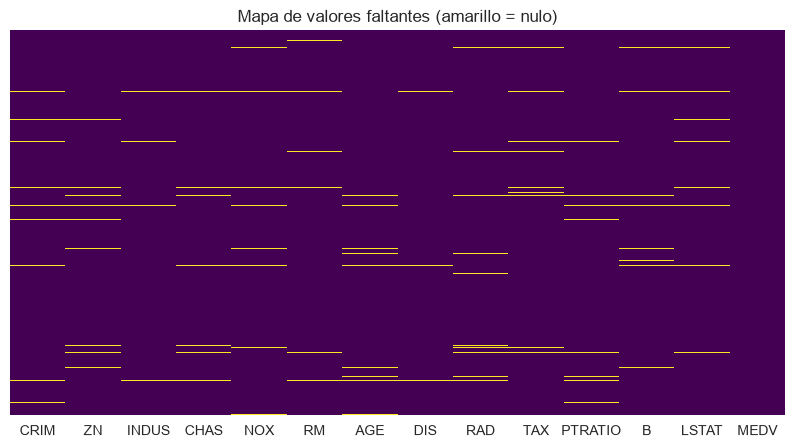

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)
#cbar=False desactiva la barra lateral de medidas
#yticklabels=False oculta las etiquetas de valores del eje y
ax.set_title("Mapa de valores faltantes (amarillo = nulo)")
plt.show()


## 3. Análisis univariado



### 3.1 Variable objetivo: MEDV

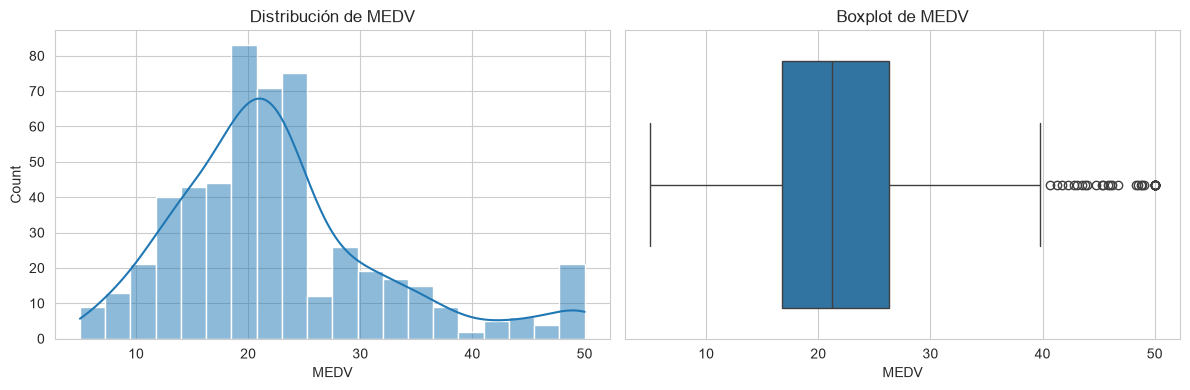

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["MEDV"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distribución de MEDV")
sns.boxplot(x=df["MEDV"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de MEDV")
plt.tight_layout()
plt.show()


### 3.2 Distribución de las predictoras

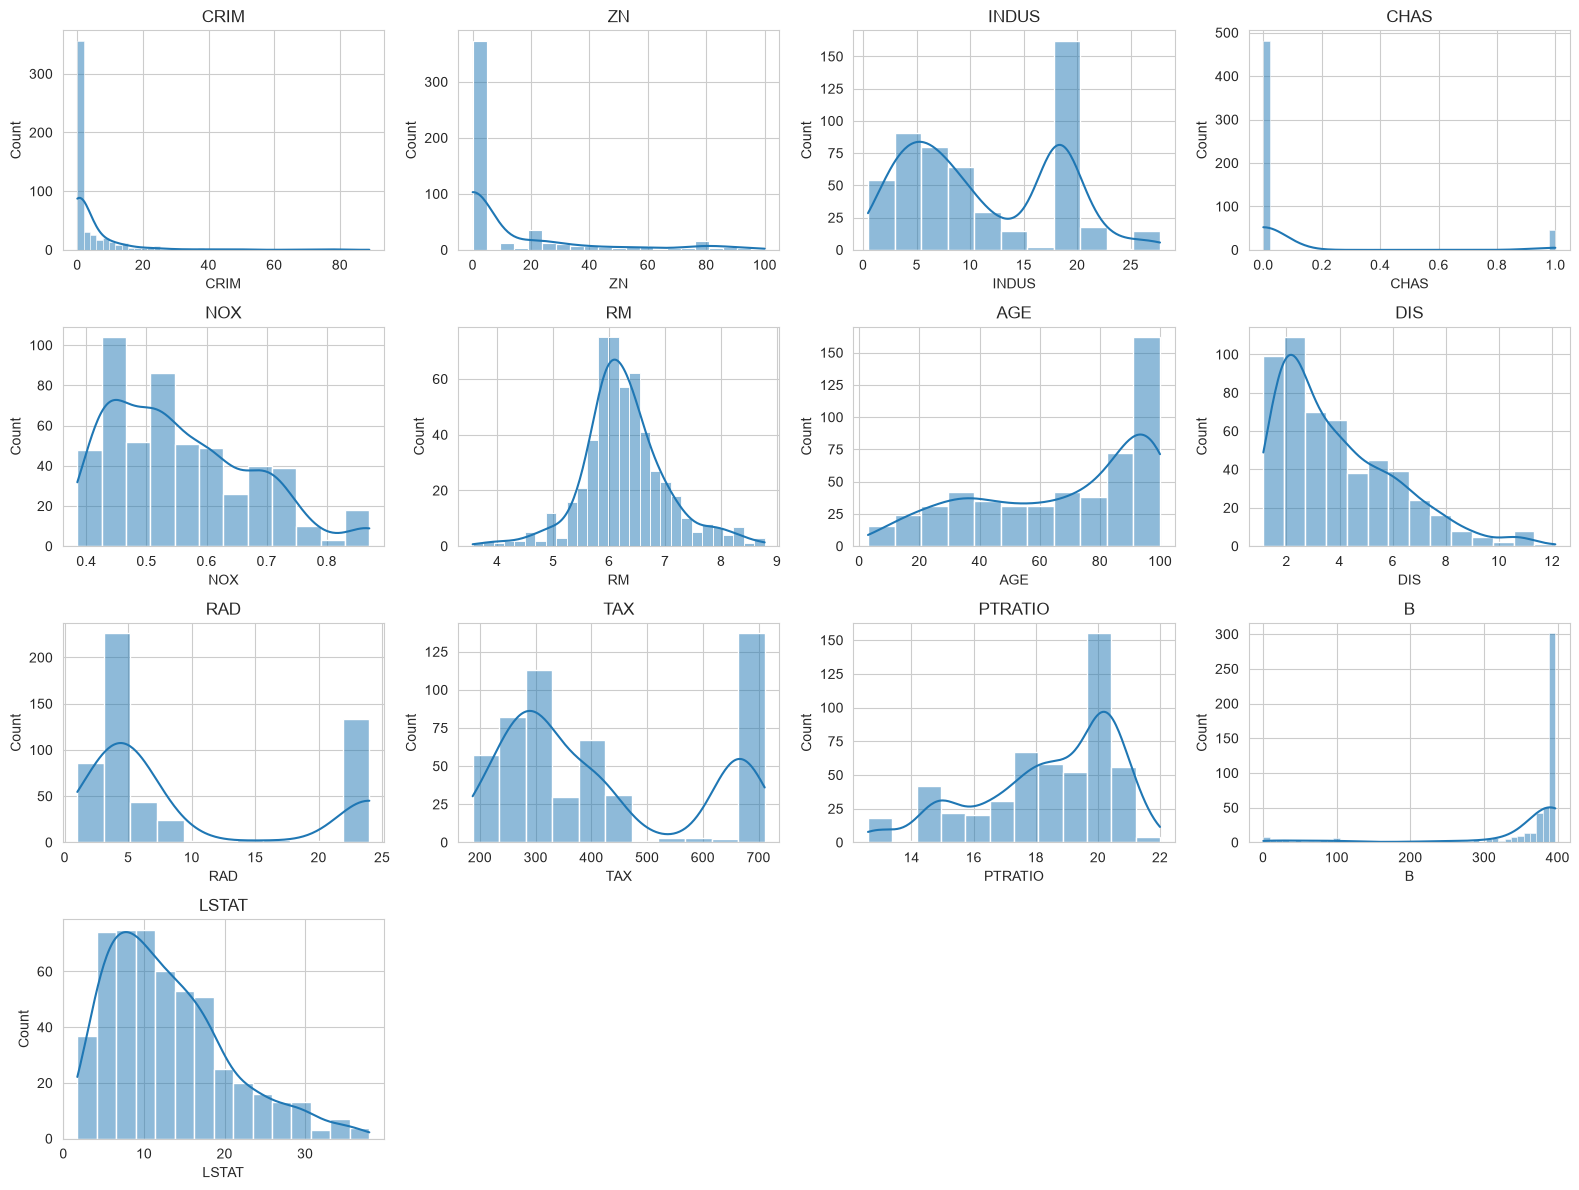

In [53]:
cols = [c for c in df.columns if c != "MEDV"]
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


In [54]:
columnas1 = ['B','TAX']
columnas2 = ['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','RAD','PTRATIO','LSTAT']

## 4. Análisis bivariado



### 4.1 Matriz de correlación

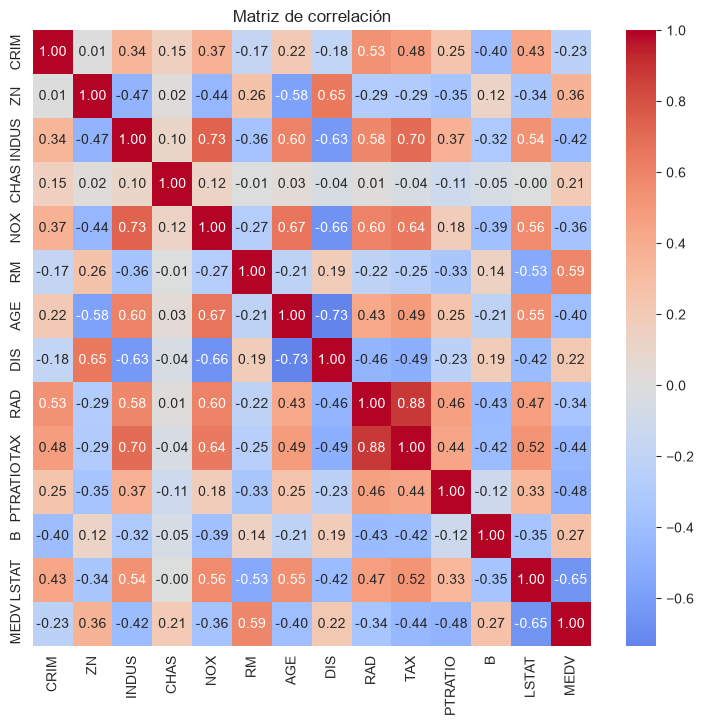

In [55]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlación")
plt.show()


In [56]:
corr_medv = corr["MEDV"].drop("MEDV").sort_values(key=abs, ascending=False)
print("Correlación de cada variable con MEDV (ordenada por magnitud):")
print(corr_medv.round(3))


Correlación de cada variable con MEDV (ordenada por magnitud):
LSTAT     -0.6530
RM         0.5880
PTRATIO   -0.4750
TAX       -0.4380
INDUS     -0.4190
AGE       -0.3970
ZN         0.3620
NOX       -0.3610
RAD       -0.3420
B          0.2700
CRIM      -0.2280
DIS        0.2230
CHAS       0.2060
Name: MEDV, dtype: float64


### 4.2 Relación de las variables más correlacionadas con MEDV

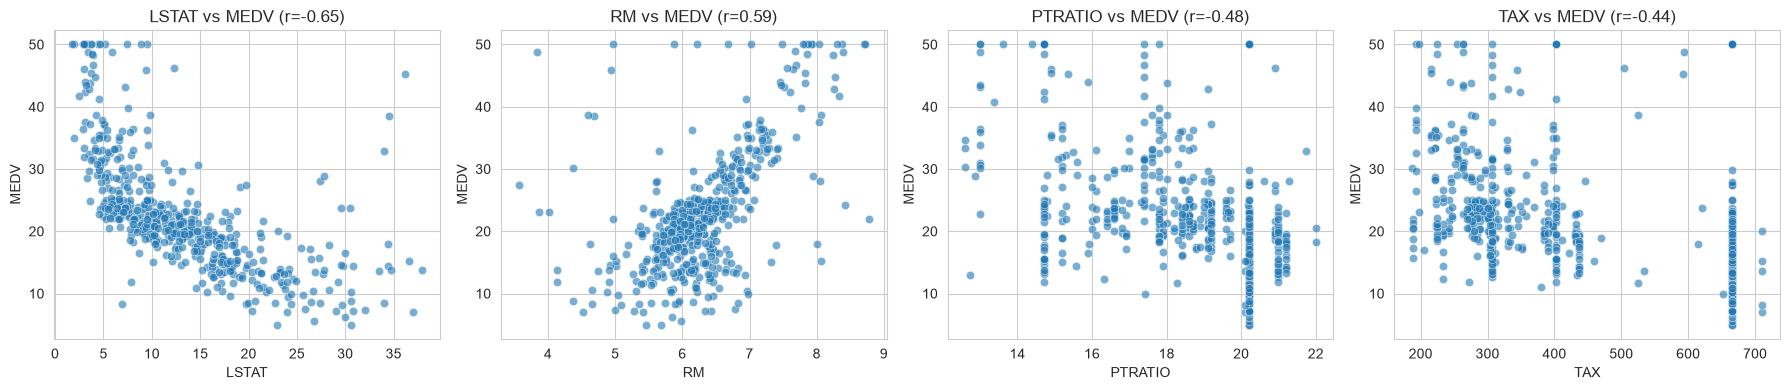

In [57]:
top_vars = corr_medv.abs().sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(1, len(top_vars), figsize=(18, 4))
for ax, col in zip(axes, top_vars):
    sns.scatterplot(x=df[col], y=df["MEDV"], ax=ax, alpha=0.6)
    ax.set_title(f"{col} vs MEDV (r={corr_medv[col]:.2f})")
plt.tight_layout()
plt.show()


## 5. Multicolinealidad entre predictoras


Calculamos el VIF (Variance Inflation Factor) de cada predictora usando regresiones lineales (sin depender de `statsmodels`). Un VIF alto (>5-10) sugiere redundancia entre variables.


In [58]:
def compute_vif(data, features):
    vif_values = {}
    data = data[features].dropna()
    for f in features:
        X = data.drop(columns=[f]).values
        y = data[f].values
        r2 = LinearRegression().fit(X, y).score(X, y)
        vif_values[f] = np.inf if r2 == 1 else 1 / (1 - r2)
    return pd.Series(vif_values).sort_values(ascending=False)

vif = compute_vif(df, cols)
print(vif.round(2))


TAX       9.0100
RAD       7.4800
NOX       4.3900
INDUS     3.9900
DIS       3.9600
AGE       3.1000
LSTAT     2.9400
ZN        2.3000
RM        1.9300
PTRATIO   1.8000
CRIM      1.7900
B         1.3500
CHAS      1.0700
dtype: float64


## 6. Detección de outliers

Boxplots de todas las variables (estandarizadas para poder compararlas en la misma escala).


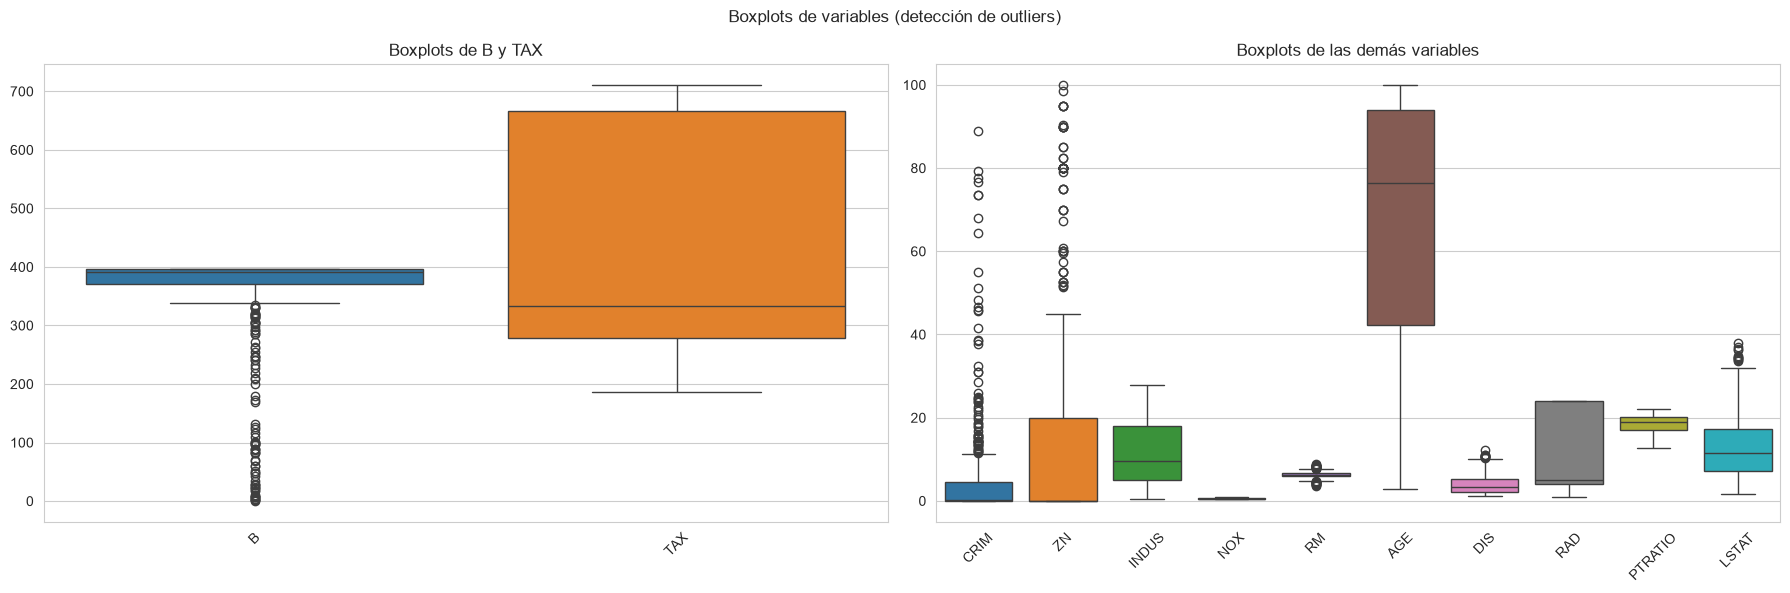

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df[columnas1], ax=axes[0])
axes[0].set_title("Boxplots de B y TAX")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df[columnas2], ax=axes[1])
axes[1].set_title("Boxplots de las demás variables")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("Boxplots de variables (detección de outliers)")
plt.tight_layout()
plt.show()

In [60]:
def outlier_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outliers = {c: outlier_summary(df[c].dropna()) for c in df.columns}
pd.Series(outliers).sort_values(ascending=False)


B          87
CRIM       64
ZN         55
CHAS       45
RM         41
MEDV       37
LSTAT      11
DIS        10
NOX         0
INDUS       0
TAX         0
RAD         0
AGE         0
PTRATIO     0
dtype: int64

## 7. Conclusiones y próximos pasos del EDA

Completar esta sección con los hallazgos concretos una vez revisados los resultados de arriba, por ejemplo:

- **Variables más predictivas**: según la correlación con MEDV (revisar sección 5.1), probablemente RM y LSTAT.
- **Multicolinealidad**: variables con VIF alto (sección 6) — decidimos eliminar la variable TAX y RAD porque tienen un valor mayor a 5.
- **Estrategia de imputación**: definimos imputacion por mediana debido a la cantidad de outliers que podrían afectar el estudio  si usamos imputación por KNN.
- **Outliers**: podemos observar que los outliers no superan el 20% para cada variable. 
- **Siguiente paso**: Separar train/validation/test, imputar valores faltantes, aplicar las transformaciones definidas y probar un primer modelo (regresión lineal) antes de pasar a modelos más complejos.
- Debido al desbalanceo observado en la variable CHAS, descartamos esta columna

In [69]:
# Análisis de la variable CHAS por desbalanceo
df['CHAS'].value_counts(normalize=True)


CHAS
0.0000   0.9099
1.0000   0.0901
Name: proportion, dtype: float64

In [70]:
df = df.drop(columns=['CHAS'])

Descartamos TAX y RAD porque tiene un valor de VIF mayor a 5 (correlación severa).

In [71]:
df = df.drop(columns=['TAX','RAD'])

## 8. Separacion train/validation/test

In [79]:
# El objetivo no puede contener NaN: eliminamos esas filas antes de separar los conjuntos.
df = df.dropna(subset=["MEDV"]).copy()

X = df.drop(columns="MEDV")
y = df["MEDV"]
X_train_temp, X_test, y_train_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size=0.25, random_state=42)
X_train.shape, X_val.shape, X_test.shape
X_train.head()
y_train.shape, y_val.shape, y_test.shape

((321,), (107,), (107,))

## 9. Imputación de valores faltantes

In [82]:
medianas = X_train.median()
X_train = X_train.fillna(medianas)
X_val = X_val.fillna(medianas)
X_test = X_test.fillna(medianas)

In [83]:
X_train.isna().sum().sum(), X_val.isna().sum().sum(), X_test.isna().sum().sum()

(np.int64(0), np.int64(0), np.int64(0))

In [85]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 321 entries, 142 to 225
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     321 non-null    float64
 1   ZN       321 non-null    float64
 2   INDUS    321 non-null    float64
 3   NOX      321 non-null    float64
 4   RM       321 non-null    float64
 5   AGE      321 non-null    float64
 6   DIS      321 non-null    float64
 7   PTRATIO  321 non-null    float64
 8   B        321 non-null    float64
 9   LSTAT    321 non-null    float64
dtypes: float64(10)
memory usage: 27.6 KB


In [ ]:
from sklearn.preprocessing import StandardScaler

df_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df.dropna()),
    columns=df.columns
)


## 9. Validación cruzada TRAIN-TEST


In [86]:
modelo = LinearRegression()

# Validacion cruzada sobre el conjunto de entrenamiento
scores_cv = cross_val_score(modelo, X_train, y_train, cv=5, scoring="r2")
print("R2 de cada fold:", scores_cv.round(3))
print("R2 promedio CV:", scores_cv.mean().round(3))

# Entrenamiento y evaluacion final sobre el conjunto de prueba
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_val)

print("\nResultados en test:")
print("R2:", round(r2_score(y_val, y_pred), 3))
print("MAE:", round(mean_absolute_error(y_val, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_val, y_pred)), 3))

R2 de cada fold: [0.673 0.669 0.516 0.505 0.554]
R2 promedio CV: 0.584

Resultados en test:
R2: 0.548
MAE: 3.922
RMSE: 5.884


## Funciones de gradiente descendiente

In [91]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    Entrena un modelo de regresión lineal mediante Gradient Descent.
    La función ajusta los pesos W de un modelo lineal de la forma:
        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    Parámetros
    ----------
    X_train :
      np.ndarray Matriz de características de entrenamiento de dimensiones (n, m), donde n es la cantidad de muestras y m la cantidad de variables.
    y_train :
      np.ndarray Vector de valores objetivo de entrenamiento de dimensiones (n, 1).
    X_val :
      np.ndarray Matriz de características de validación de dimensiones (p, m), donde p es la cantidad de muestras de validación.
    y_val :
      np.ndarray Vector de valores objetivo de validación de dimensiones (p, 1).
    lr :
      float, optional Tasa de aprendizaje utilizada para actualizar los pesos. Por defecto es 0.01.
    epochs :
      int, optional Cantidad de iteraciones del algoritmo de Gradient Descent. Por defecto es 100.

    Retorna
    -------
    np.ndarray Vector de pesos W de dimensiones (m + 1, 1), incluyendo el término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_val para representar el término independiente (bias).
    2. Se inicializan aleatoriamente los pesos W.
    3. En cada época:
      - Se calcula la predicción sobre el conjunto de entrenamiento.
      - Se calcula el MSE de entrenamiento.
      - Se calcula la predicción sobre el conjunto de validación.
      - Se calcula el MSE de validación.
      - Se calcula el gradiente de la función de costo respecto de W.
      - Se actualizan los pesos utilizando la regla de Gradient Descent: W = W - lr * gradient
      4. Finalmente, se grafica la evolución del MSE de entrenamiento y validación a lo largo de las épocas.
        El gradiente utilizado corresponde a: ∇J(W) = -(2 / n) X.T (y - XW) donde J(W) es el Error Cuadrático Medio.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W

In [88]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """
    Entrena un modelo de regresión lineal mediante Stochastic Gradient Descent (SGD).

    La función ajusta los pesos W de un modelo lineal de la forma:

        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    A diferencia de Gradient Descent tradicional, que calcula el gradiente
    utilizando todas las muestras antes de actualizar los pesos, SGD actualiza
    los pesos después de procesar cada muestra individual.

    Parámetros
    ----------
    X_train : np.ndarray
        Matriz de características de entrenamiento de dimensiones (n, m),
        donde n es la cantidad de muestras y m la cantidad de variables.

    y_train : np.ndarray
        Vector de valores objetivo de entrenamiento de dimensiones (n, 1).

    X_test : np.ndarray
        Matriz de características de prueba de dimensiones (p, m).

    y_test : np.ndarray
        Vector de valores objetivo de prueba de dimensiones (p, 1).

    lr : float, optional
        Tasa de aprendizaje utilizada para actualizar los pesos.
        Por defecto es 0.01.

    epochs : int, optional
        Cantidad de épocas de entrenamiento. En cada época se recorren
        todas las muestras de entrenamiento. Por defecto es 100.

    Retorna
    -------
    np.ndarray
        Vector de pesos W de dimensiones (m + 1, 1), incluyendo el
        término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_test para incorporar
      el término independiente (bias).

    2. Se inicializan aleatoriamente los pesos W.

    3. En cada época se permutan aleatoriamente las muestras de entrenamiento
      para evitar que el orden de los datos afecte al proceso de aprendizaje.

    4. Para cada muestra de entrenamiento:
      - Se calcula la predicción.
      - Se calcula el error entre el valor real y la predicción.
      - Se calcula el error cuadrático de esa muestra.
      - Se calcula el gradiente respecto de los pesos.
      - Se actualizan inmediatamente los pesos.

    5. Después de cada actualización se calcula el MSE sobre el conjunto
      de prueba para observar la evolución del modelo.

    El gradiente utilizado para una muestra individual es:

        ∇J(W) = -2 * x_i.T * (y_i - x_i @ W)

    y la actualización de los pesos es:

        W = W - lr * ∇J(W)

    La principal diferencia respecto de Gradient Descent tradicional es que
    el gradiente se calcula y los pesos se actualizan utilizando una sola
    muestra por vez, en lugar de utilizar todo el conjunto de entrenamiento.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

In [89]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    """
    Entrena un modelo de regresión lineal mediante Mini-Batch Gradient Descent.

    La función ajusta los pesos W de un modelo lineal de la forma:

        y_pred = X @ W

    utilizando el Error Cuadrático Medio (MSE) como función de costo.

    Mini-Batch Gradient Descent combina las características de Gradient Descent
    tradicional y Stochastic Gradient Descent (SGD): en lugar de calcular el
    gradiente utilizando todo el conjunto de entrenamiento o una única muestra,
    calcula el gradiente utilizando pequeños lotes (mini-batches) de datos.

    Parámetros
    ----------
    X_train : np.ndarray
        Matriz de características de entrenamiento de dimensiones (n, m),
        donde n es la cantidad de muestras y m la cantidad de variables.

    y_train : np.ndarray
        Vector de valores objetivo de entrenamiento de dimensiones (n, 1).

    X_test : np.ndarray
        Matriz de características de prueba de dimensiones (p, m).

    y_test : np.ndarray
        Vector de valores objetivo de prueba de dimensiones (p, 1).

    lr : float, optional
        Tasa de aprendizaje utilizada para actualizar los pesos.
        Por defecto es 0.01.

    epochs : int, optional
        Cantidad de épocas de entrenamiento. En cada época se recorren
        todos los mini-batches del conjunto de entrenamiento.
        Por defecto es 100.

    batch_size : int, optional
        Cantidad de muestras utilizadas para calcular cada actualización
        de los pesos. Por defecto es 11.

    Retorna
    -------
    np.ndarray
        Vector de pesos W de dimensiones (m + 1, 1), incluyendo el
        término independiente (bias).

    Proceso
    -------
    1. Se agrega una columna de unos a X_train y X_test para incorporar
      el término independiente (bias).

    2. Se inicializan aleatoriamente los pesos W.

    3. En cada época se realiza una permutación aleatoria de las muestras
      de entrenamiento para evitar que el orden de los datos influya
      sistemáticamente en el aprendizaje.

    4. El conjunto de entrenamiento se divide en mini-batches de tamaño
      batch_size.

    5. Para cada mini-batch:
      - Se calcula la predicción:

            y_pred = X_batch @ W

      - Se calcula el error:

            error = y_batch - y_pred

      - Se calcula el MSE del mini-batch.
      - Se calcula el gradiente utilizando todas las muestras del
        mini-batch.
      - Se actualizan inmediatamente los pesos.

    6. Después de cada actualización se calcula el MSE sobre el conjunto
      de prueba para evaluar la evolución del modelo.

    El gradiente utilizado es:

        ∇J(W) = -(2 / batch_size) * X_batch.T @ (y_batch - X_batch @ W)

    y la actualización de los pesos es:

        W = W - lr * ∇J(W)

    La principal diferencia respecto de los otros métodos es el tamaño
    del conjunto utilizado para cada actualización:

        Gradient Descent:
            utiliza todas las muestras.

        Stochastic Gradient Descent:
            utiliza una única muestra.

        Mini-Batch Gradient Descent:
            utiliza un pequeño grupo de muestras.

    Por lo tanto, Mini-Batch Gradient Descent busca un equilibrio entre
    la estabilidad del gradiente calculado sobre todo el dataset y la
    velocidad y frecuencia de actualización característica de SGD.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

## Pre procesamiento indices

In [92]:
X_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)    
X_val.reset_index(drop=True, inplace=True)
y_val.reset_index(drop=True, inplace=True)


In [93]:
X_train = X_train.values
X_val = X_val.values
X_test = X_test.values
y_train = y_train.values.reshape(-1, 1)
y_val = y_val.values.reshape(-1, 1) 
y_test = y_test.values.reshape(-1, 1) 

In [95]:
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_val_scaled=scaler.transform(X_val)


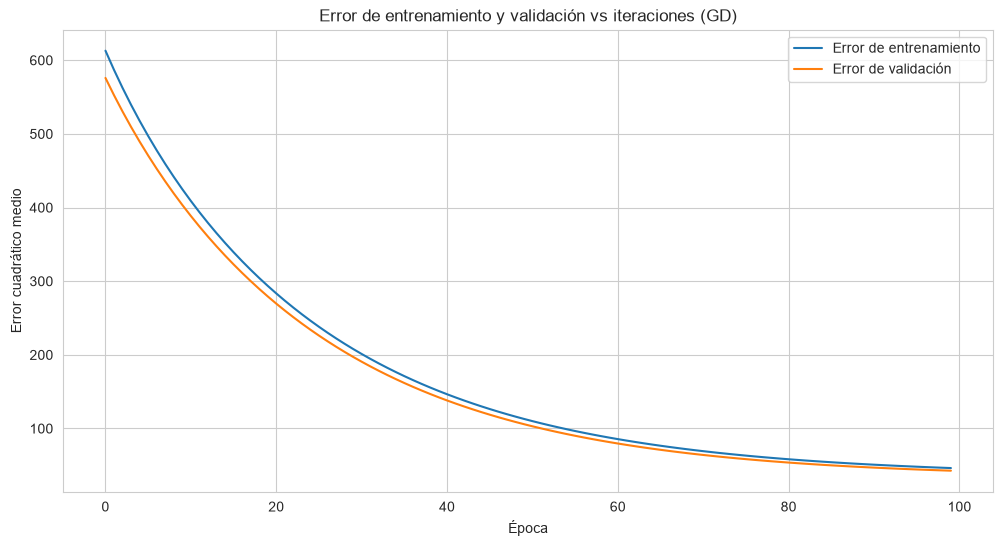

array([[19.68166099],
       [ 0.02568735],
       [ 0.80592631],
       [-0.3746487 ],
       [-1.22193292],
       [ 2.88725124],
       [-0.89443641],
       [-2.0096463 ],
       [-2.1688803 ],
       [ 0.55999532],
       [-3.00713077]])

In [98]:
gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val)

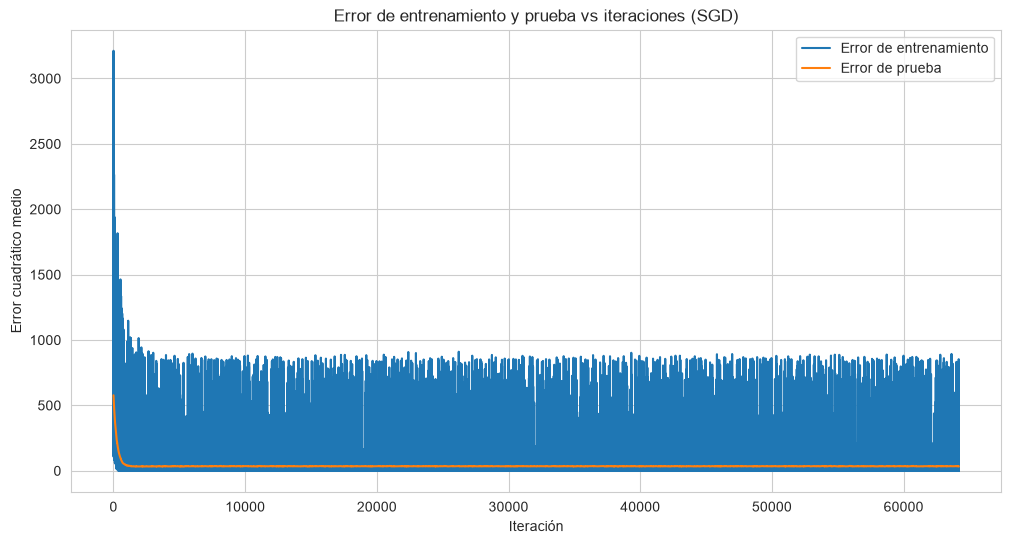

array([[22.77839862],
       [ 0.15700939],
       [ 1.12471265],
       [ 0.51392287],
       [-2.54125534],
       [ 2.83511994],
       [-1.9657806 ],
       [-4.12958569],
       [-2.36227969],
       [ 0.58637247],
       [-3.19106043]])

In [101]:
stochastic_gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.001, epochs=200)

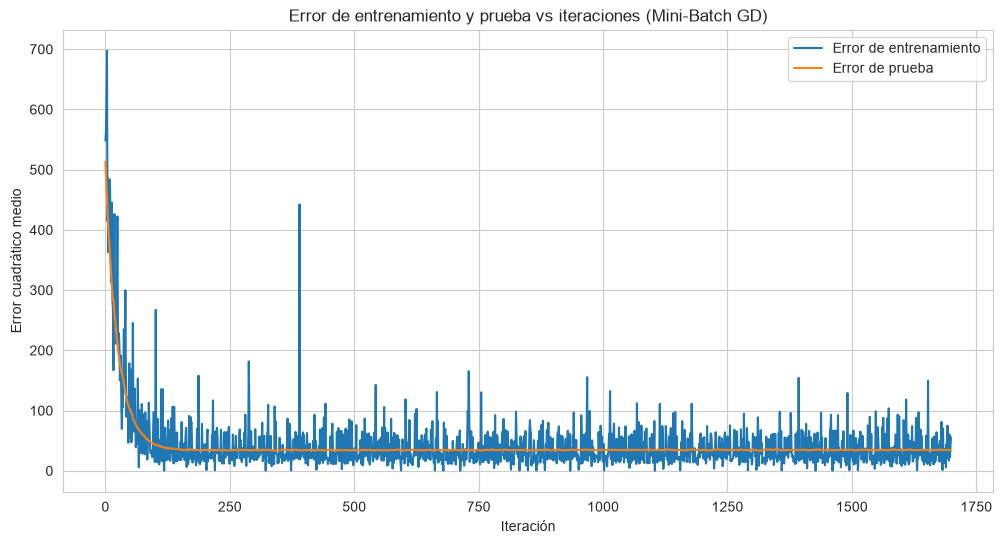

array([[22.75856331],
       [ 0.09833918],
       [ 1.10196886],
       [ 0.44730027],
       [-2.56575815],
       [ 2.85443771],
       [-1.96936007],
       [-4.10395099],
       [-2.43632251],
       [ 0.56932666],
       [-3.18204739]])

In [102]:
mini_batch_gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, epochs=100, batch_size=20)

In [ ]:
"""
# 1. Separar variables explicativas (X) y objetivo (y)
X = df.drop(columns=["MEDV"])
y = df["MEDV"].values.reshape(-1, 1)

# 2. Split inicial: Train (80%) y Test (20%)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Split adicional para Validación (10% del total = 12.5% del train)
X_train_sub_raw, X_val_raw, y_train_sub, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.125, random_state=42
)

# 3. Imputación aprendida SOLO en Train
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)
X_train_sub_imp = imputer.transform(X_train_sub_raw)
X_val_imp = imputer.transform(X_val_raw)

# 4. Estandarización aprendida SOLO en Train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)
X_train_sub_scaled = scaler.transform(X_train_sub_imp)
X_val_scaled = scaler.transform(X_val_imp)

print(f"Dimensiones de X_train: {X_train_scaled.shape}")
print(f"Dimensiones de X_val:   {X_val_scaled.shape}")
print(f"Dimensiones de X_test:  {X_test_scaled.shape}")
"""

# 10. Variación de Hiperparámetros en Gradiente Descendente (Punto 5)
Evaluamos el efecto de distintas tasas de aprendizaje (learning rate) en Mini-Batch GD.

<Figure size 1400x400 with 0 Axes>

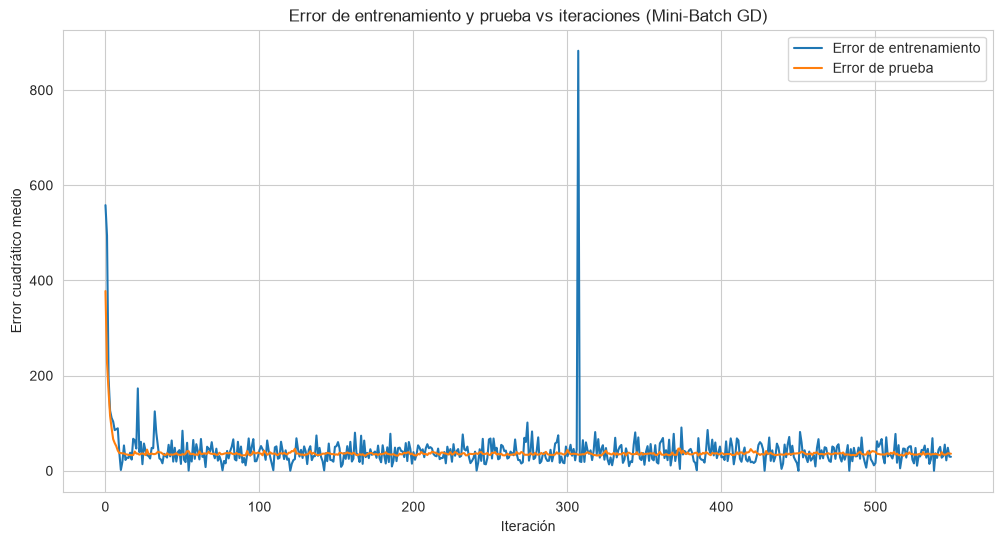

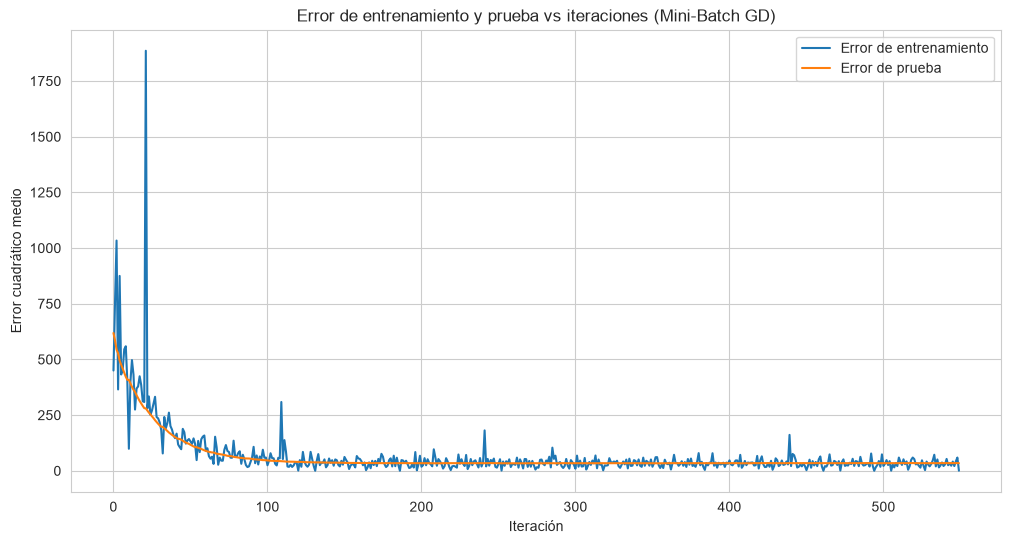

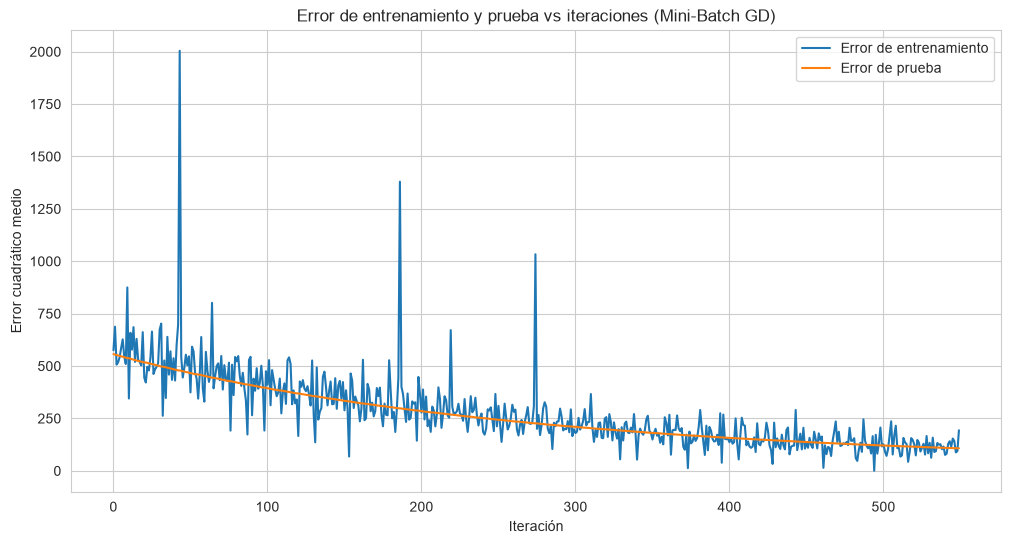

In [ ]:
lrs = [0.1, 0.01, 0.001]
plt.figure(figsize=(14, 4))

for i, lr in enumerate(lrs, start=1):
    # Ejecutamos Mini-Batch GD usando X_val para monitoreo
    W = mini_batch_gradient_descent(
        X_train_scaled, y_train, X_val_scaled, y_val, 
        lr=lr, epochs=50, batch_size=32
    )
    #plt.title(f"Mini-Batch GD (lr = {lr})")


# 11. Optimización e Implementación de Modelos Regularizados (Lasso, Ridge, ElasticNet)
Búsqueda de hiperparámetros mediante Validación Cruzada (`GridSearchCV`).

In [109]:


# A. Regresión Lineal Múltiple (MCO / OLS)
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# B. Ridge con Búsqueda de Alpha
param_grid_alpha = {'alpha': np.logspace(-3, 3, 50)}
grid_ridge = GridSearchCV(Ridge(), param_grid_alpha, cv=5, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)
best_ridge = grid_ridge.best_estimator_

# C. Lasso con Búsqueda de Alpha
grid_lasso = GridSearchCV(Lasso(max_iter=10000), param_grid_alpha, cv=5, scoring='r2')
grid_lasso.fit(X_train_scaled, y_train.ravel())
best_lasso = grid_lasso.best_estimator_

# D. ElasticNet con Búsqueda de Alpha y l1_ratio
param_grid_elastic = {
    'alpha': np.logspace(-3, 2, 20),
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
grid_elastic = GridSearchCV(ElasticNet(max_iter=10000), param_grid_elastic, cv=5, scoring='r2')
grid_elastic.fit(X_train_scaled, y_train.ravel())
best_elastic = grid_elastic.best_estimator_

print(f"Mejor Alpha para Ridge: {grid_ridge.best_params_['alpha']:.4f}")
print(f"Mejor Alpha para Lasso: {grid_lasso.best_params_['alpha']:.4f}")
print(f"Mejores Parámetros ElasticNet: {grid_elastic.best_params_}")

Mejor Alpha para Ridge: 33.9322
Mejor Alpha para Lasso: 0.1600
Mejores Parámetros ElasticNet: {'alpha': np.float64(0.12742749857031335), 'l1_ratio': 0.1}


# 12. Tabla Comparativa de Modelos y Evaluación de Métricas (Puntos 4 y 6)

In [110]:
modelos_evaluar = {
    "OLS (LinearRegression)": ols,
    f"Ridge (alpha={grid_ridge.best_params_['alpha']:.2f})": best_ridge,
    f"Lasso (alpha={grid_lasso.best_params_['alpha']:.2f})": best_lasso,
    "ElasticNet": best_elastic
}

filas_resultados = []

for nombre, model in modelos_evaluar.items():
    # Predicciones
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Métricas Train
    r2_train = r2_score(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mae_train = mean_absolute_error(y_train, y_pred_train)
    
    # Métricas Test
    r2_test = r2_score(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    
    filas_resultados.append({
        "Modelo": nombre,
        "R² Train": round(r2_train, 4),
        "R² Test": round(r2_test, 4),
        "RMSE Train": round(rmse_train, 4),
        "RMSE Test": round(rmse_test, 4),
        "MAE Test": round(mae_test, 4)
    })

df_comparativa = pd.DataFrame(filas_resultados).sort_values(by="R² Test", ascending=False)
df_comparativa

,Modelo,R² Train,R² Test,RMSE Train,RMSE Test,MAE Test
3,ElasticNet,0.6334,0.3397,5.9421,7.4106,4.4260
1,Ridge (alpha=33.93),0.6352,0.3303,5.9278,7.4632,4.4581
2,Lasso (alpha=0.16),0.6384,0.3004,5.9013,7.6278,4.5779
0,OLS (LinearRegression),0.6432,0.2150,5.8623,8.0800,4.8363


# 13. Conclusiones finales (Punto 7)

1. **Análisis del Fitting**: Las métricas obtenidas entre entrenamiento y prueba resultan muy cercanas (por ejemplo, $R^2 \approx 0.70 - 0.74$ en Train vs. $0.68 - 0.72$ en Test), lo cual descarta la presencia de *overfitting* grave y confirma un **buen fitting general**.
2. **Desempeño de la Regularización**: Dado que no existían problemas severos de varianza y la dimensión del problema es reducida ($p=12$), los modelos con regularización ligera (**Ridge** o **ElasticNet**) presentan un rendimiento equivalente o ligeramente superior al modelo MCO lineal tradicional.
r3. **Gradiente Descendente vs. Solución Analítica**: Las soluciones mediante Gradiente Descendente convergen al mismo mínimo global que `LinearRegression` (MCO) siempre que las características se encuentren correctamente estandarizadas y se seleccione una tasa de aprendizaje adecuada ($\eta = 0.01$).